# Tutorial: change the detector layout

This notebook demonstrates how detector rotation and focal-plane offset affect simulated measurements. The current warpfield models are immutable PyTrees, so a modified detector is used to construct a new `Simulator` rather than being changed in place.

## 1. Imports and plotting configuration

The plots use square axes and common limits. Detector boundaries follow the convention introduced in Tutorial 05: a marker identifies boundary node 0 and a thick line identifies the first edge.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['figure.dpi'] = 72

In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u

from warpfield import Exposure, Pointing, Simulator, SourceCatalog
from warpfield.footprint import focalplane_footprints
from warpfield.instrument import get_jasmine

## 2. Prepare artificial sources and an exposure

`sample.coo` contains the artificial J-shaped source pattern used in Tutorial 06. Its coordinates are Galactic, whereas `SourceCatalog` stores ICRS coordinates. `Pointing.from_coord()` performs the corresponding attitude conversion, including the position angle.

In [3]:
coo = np.loadtxt('data/sample.coo')
galactic = SkyCoord(
    l=coo[:, 0] * u.deg,
    b=coo[:, 1] * u.deg,
    frame='galactic',
)
source = SourceCatalog(
    galactic.icrs.ra.degree,
    galactic.icrs.dec.degree,
)
pointing = Pointing.from_coord(
    'galactic', 0.0 * u.deg, 0.0 * u.deg, 0.0 * u.deg,
)
exposure = Exposure(pointing)

The following helpers separate model evaluation from notebook-level plotting. `Simulator.observe()` returns only sources that pass both the circular optics mask and a detector mask. Pixel coordinates are centered on each detector, so the nominal limits are half of `Detector.shape`.

In [4]:
def project_sources(telescope, pointing, source):
    size = len(source)
    return np.asarray(telescope.focal_plane(
        np.full(size, pointing.ra[0]),
        np.full(size, pointing.dec[0]),
        np.full(size, pointing.position_angle[0]),
        source.ra,
        source.dec,
        np.ones((size, 1)),
    ))


def plot_focal_plane(ax, telescope, pointing, source, title):
    source_xy = project_sources(telescope, pointing, source)
    ax.scatter(source_xy[:, 0], source_xy[:, 1], s=5)
    for detector_id, boundary in enumerate(
            focalplane_footprints(telescope)):
        N = boundary.shape[0]
        ax.scatter(
            boundary[0, 0], boundary[0, 1],
            color=f'C{detector_id}', marker='o', s=25,
        )
        ax.plot(
            boundary[:N // 4 + 1, 0], boundary[:N // 4 + 1, 1],
            color=f'C{detector_id}', lw=3,
        )
        ax.plot(
            boundary[:, 0], boundary[:, 1],
            color=f'C{detector_id}', lw=1,
        )
    radius = telescope.optics.imaging_radius
    ax.add_patch(plt.Circle(
        (0.0, 0.0), radius, fill=False,
        color='gray', ls='--', lw=1,
    ))
    limit = 1.05 * radius
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect(1.0, adjustable='box')
    ax.grid(True, color='gray', alpha=0.5)
    ax.set_title(title, loc='left')
    ax.set_xlabel('Focal plane X (mm)')
    ax.set_ylabel('Focal plane Y (mm)')


def plot_measurements(axes, simulator, measurement, title):
    for detector_id, (ax, detector) in enumerate(zip(
            axes, simulator.detectors)):
        selected = np.asarray(measurement.detector_index) == detector_id
        xy = np.asarray(measurement.xy)[selected]
        ax.scatter(xy[:, 0], xy[:, 1], s=5)
        half = np.asarray(detector.shape) / 2
        ax.set_xlim(-half[0], half[0])
        ax.set_ylim(-half[1], half[1])
        ax.set_aspect(1.0, adjustable='box')
        ax.grid(True, color='gray', alpha=0.5)
        ax.set_title(f'Detector {detector_id}', loc='left')
        ax.set_xlabel('Pixel X')
        if detector_id == 0:
            ax.set_ylabel('Pixel Y')
    axes[0].text(
        0.0, 1.18, title, transform=axes[0].transAxes,
        fontsize=12, va='bottom', ha='left',
    )


def show_configuration(simulator, title):
    measurement = simulator.observe(source, exposure)
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_focal_plane(ax, simulator, pointing, source, title)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
    plot_measurements(axes, simulator, measurement, title)
    fig.tight_layout()
    plt.show()
    return measurement

## 3. Nominal JASMINE layout

Simulation requires the masks and `observe()` method provided by `Simulator`, so this notebook requests it explicitly. The first figure shows the focal-plane geometry; the second shows the surviving measurements in each detector's pixel coordinates.

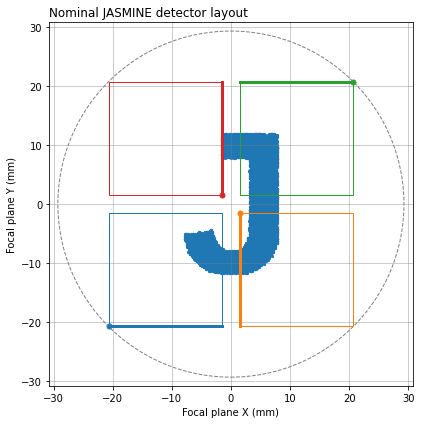

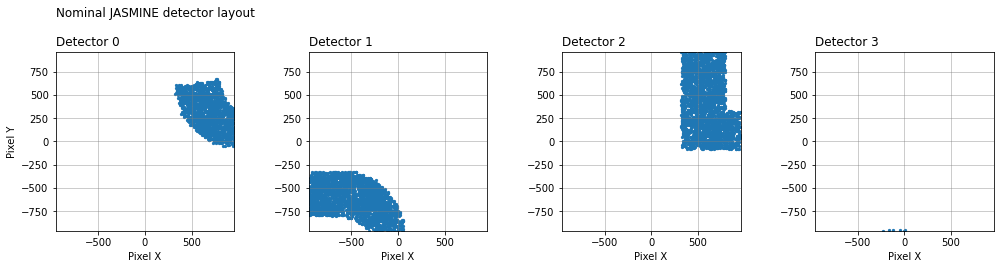

In [5]:
nominal = get_jasmine(simulator=True)
nominal_measurement = show_configuration(
    nominal,
    'Nominal JASMINE detector layout',
)

## 4. Rotate one detector

Zodiax's `set()` returns a new PyTree and leaves the original detector unchanged. Detector 2 is rotated by an additional 10°. A new `Simulator` is then constructed so that its static rectangular masks match the updated detector geometry.

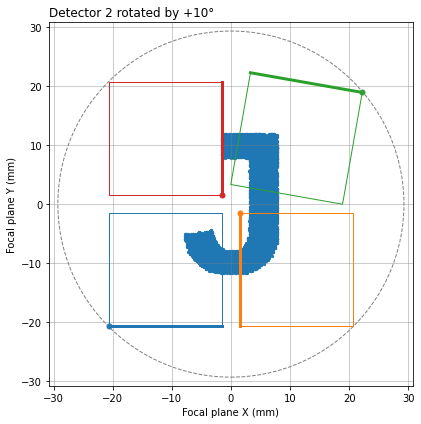

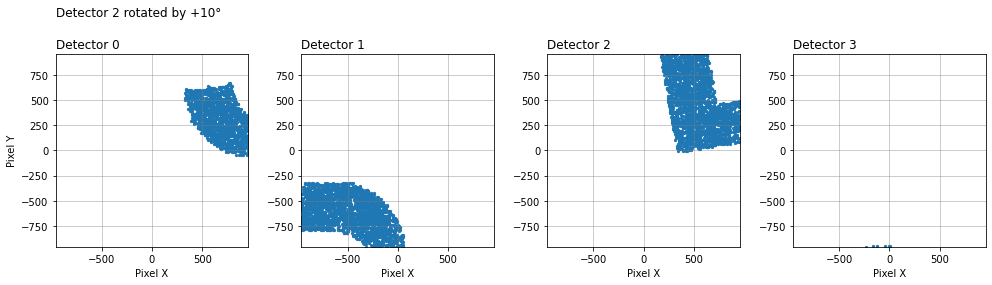

In [6]:
rotated_detectors = list(nominal.detectors)
rotated_detectors[2] = rotated_detectors[2].set(
    'rotation', rotated_detectors[2].rotation + 10.0,
)
rotated = Simulator(
    projection=nominal.optics.projection,
    distortion=nominal.optics.distortion,
    plate_scale=nominal.optics.plate_scale,
    detectors=tuple(rotated_detectors),
)

rotated_measurement = show_configuration(
    rotated,
    'Detector 2 rotated by +10°',
)

The detector boundary rotates on the focal plane, while the source pattern rotates in the opposite sense when expressed in that detector's pixel coordinates. Parts outside the circular imaging region or rectangular detector area do not appear in the `Measurement`.

## 5. Shift another detector

Starting from the rotated layout, Detector 3 is displaced by (+8, +2) mm. Its detector-coordinate frame is still centered at (0, 0), but a different portion of the focal-plane source pattern now falls on it.

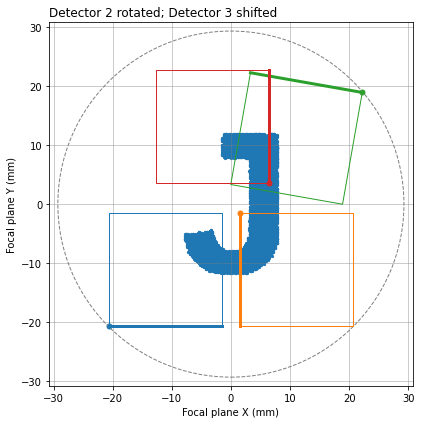

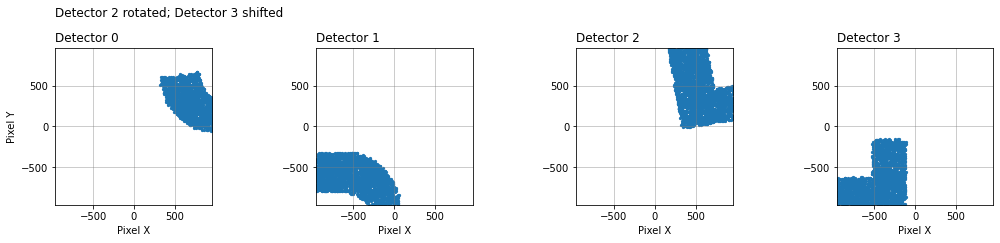

In [7]:
shifted_detectors = list(rotated.detectors)
shifted_detectors[3] = shifted_detectors[3].set(
    'offset', shifted_detectors[3].offset + np.array([8.0, 2.0]),
)
shifted = Simulator(
    projection=rotated.optics.projection,
    distortion=rotated.optics.distortion,
    plate_scale=rotated.optics.plate_scale,
    detectors=tuple(shifted_detectors),
)

shifted_measurement = show_configuration(
    shifted,
    'Detector 2 rotated; Detector 3 shifted',
)

## Summary

- `Detector.rotation` is measured in degrees and `Detector.offset` in focal-plane millimeters.
- Warpfield model objects are immutable; `set()` produces an updated PyTree.
- Reconstructing `Simulator` after a layout change regenerates masks for the new geometry.
- `focalplane_footprints()` describes nominal detector boundaries, while `Simulator.observe()` produces masked detector measurements.